In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Covid Data.csv')
print(df.shape)
df.head()

(1048575, 21)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [5]:
df.replace([97, 98, 99], np.nan, inplace=True)
df.drop(columns=['DATE_DIED'], inplace=True)
df.dropna(inplace=True)

df['target'] = df['CLASIFFICATION_FINAL'].apply(lambda x: 1 if x <= 3 else 0)
df.drop(columns=['CLASIFFICATION_FINAL'], inplace=True)

In [6]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

modeller = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for isim, model in modeller.items():
    model.fit(X_train, y_train)
    tahmin = model.predict(X_test)
    print(f"--- {isim} Sonuçları ---")
    print("Doğruluk:", accuracy_score(y_test, tahmin))
    print(classification_report(y_test, tahmin))
    print("\n")

--- Logistic Regression Sonuçları ---
Doğruluk: 0.6323778501628664
              precision    recall  f1-score   support

           0       0.63      0.51      0.57      7158
           1       0.63      0.74      0.68      8192

    accuracy                           0.63     15350
   macro avg       0.63      0.62      0.62     15350
weighted avg       0.63      0.63      0.63     15350



--- KNN Sonuçları ---
Doğruluk: 0.5913355048859935
              precision    recall  f1-score   support

           0       0.57      0.52      0.54      7158
           1       0.61      0.66      0.63      8192

    accuracy                           0.59     15350
   macro avg       0.59      0.59      0.59     15350
weighted avg       0.59      0.59      0.59     15350



--- Decision Tree Sonuçları ---
Doğruluk: 0.5884690553745928
              precision    recall  f1-score   support

           0       0.56      0.56      0.56      7158
           1       0.61      0.61      0.61      8192


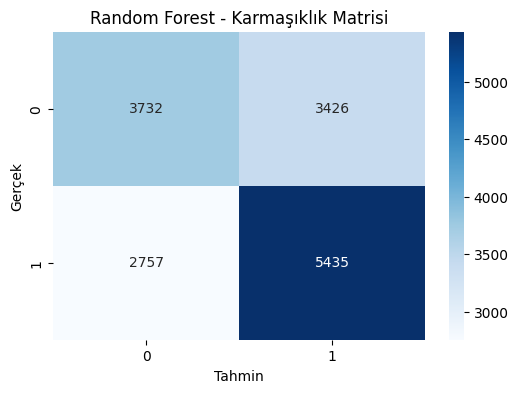

In [8]:
from sklearn.metrics import confusion_matrix

model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)
tahmin_rf = model_rf.predict(X_test)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, tahmin_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()